<a target="_blank" href="https://colab.research.google.com/github/robgen/HEDSpython/blob/main/Tutorial_5.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **APIs**

API stands for Application Program Interface and is a way for two or more computer programmes to communicate with each other.

REST (Representational State Transfer) APIs allow communication between a client (your program) and a server (usually online) using HTTP (HyperText Transfer Protocol) to communicate.

A HTTP request is sent from client to server containing the instructions in a file (usually .json). The server then executes the instructions and sends a HTTP response which contains the result.

Let's look at an example.

In [1]:
import requests
import json
import pandas

We first define the HTTP request providing the appropriate URL.

In [2]:
country = 'Italy'
daterange = '20211215-20220115'
url = ('https://covidmap.umd.edu/apiv2/resources?indicator=covid&type=smoothed&country=' +
    country + '&daterange=' + daterange )
url

'https://covidmap.umd.edu/apiv2/resources?indicator=covid&type=smoothed&country=Italy&daterange=20211215-20220115'

We then send request via API and collect the text response using the `get()` function.

In [3]:
response = requests.get(url, verify=False)
print(response)

ConnectionError: HTTPSConnectionPool(host='covidmap.umd.edu', port=443): Max retries exceeded with url: /apiv2/resources?indicator=covid&type=smoothed&country=Italy&daterange=20211215-20220115 (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7dcacec90dd0>: Failed to establish a new connection: [Errno 113] No route to host'))

We can get a number of API responses the key ones to remember are:

*   200 - success
*   400 - bad request (i.e., the error is in our code)
*   500 - internal server error (i.e., the error is on the server side)


We then transform the text response in a json file. a json is a JavaScript Object Notation consisting of name-object pairs and punctuation in the form of brackets, parentheses, semicolons and colons (basically a big dictionary!)

In [ ]:
jsonData = json.loads(response.text)
print(jsonData)

And lastly convert the json to a pandas dataframe - ready for us to use.

In [ ]:
df = pandas.DataFrame.from_dict(jsonData['data'])
df.head()

## **Using World Bank Data API**

You can find the documentation on the API interface and practical examples [here](https://wbdata.readthedocs.io/en/stable/) and [here](https://blogs.worldbank.org/opendata/accessing-world-bank-data-apis-python-r-ruby-stata) respectively.

Let's replicate the example code below.

We first need to install the `wbdata` library which contains the API call.

In [4]:
!pip3 install -U wbdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 8.1 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.0
    Uninstalling cachetools-7.0.0:
      Successfully uninstalled cachetools-7.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


We then import the libraries.

In [1]:
import wbdata
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

The `get_country()` function gives us a list of all countries.  

In [2]:
wbdata.get_countries()

id    name
----  --------------------------------------------------------------------------------
ABW   Aruba
AFE   Africa Eastern and Southern
AFG   Afghanistan
AFR   Africa
AFW   Africa Western and Central
AGO   Angola
ALB   Albania
AND   Andorra
ARB   Arab World
ARE   United Arab Emirates
ARG   Argentina
ARM   Armenia
ASM   American Samoa
ATG   Antigua and Barbuda
AUS   Australia
AUT   Austria
AZE   Azerbaijan
BDI   Burundi
BEA   East Asia & Pacific (IBRD-only countries)
BEC   Europe & Central Asia (IBRD-only countries)
BEL   Belgium
BEN   Benin
BFA   Burkina Faso
BGD   Bangladesh
BGR   Bulgaria
BHI   IBRD countries classified as high income
BHR   Bahrain
BHS   Bahamas, The
BIH   Bosnia and Herzegovina
BLA   Latin America & the Caribbean (IBRD-only countries)
BLR   Belarus
BLZ   Belize
BMN   Middle East, North Africa, Afghanistan & Pakistan (IBRD only)
BMU   Bermuda
BOL   Bolivia
BRA   Brazil
BRB   Barbados
BRN   Brunei Darussalam
BSS   Sub-Saharan Africa (IBRD-only countries)
BTN  

We can pick the countries that interest us.

In [3]:
countries = ["USA","GBR","ITA"]

The `get_indicator()` function gives us a list of all indicators.

In [4]:
wbdata.get_indicators()

id                                                 name
-------------------------------------------------  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1.0.HCount.1.90usd                                 Poverty Headcount ($1.90 a day)
1.0.HCount.2.5usd                                  Poverty Headcount ($2.50 a day)
1.0.HCount.Mid10to50                               Middle Class ($10-50 a day) Headcount
1.0.HCount.Ofcl                                    Official Moderate Poverty Rate-National
1.0.HCount.Poor4uds                                Poverty Headcount ($4 a day)
1.0.HCount.Vul4to10                                Vulnerable ($4-10 a day) Headcount
1.0.PGap.1.90usd                                   Poverty Gap ($1.90 a day)
1.0.PGap.2.5usd      

We can choose the indicator that we want.

In [5]:
indicators = {'NY.GNP.PCAP.CD':'GNI per Capita'}

We then make the call using the country and indicators parameters.

In [20]:
df = wbdata.get_dataframe(indicators, country=countries, parse_dates=False)

In [21]:
df

GNI per Capita
country        date                
United Kingdom 2024         49470.0
               2023         48830.0
               2022         49720.0
               2021         45870.0
               2020         39340.0
...                             ...
United States  1964          3580.0
               1963          3390.0
               1962          3260.0
               1961             NaN
               1960             NaN

[195 rows x 1 columns]

The df is given as a pivot table. Pandas' `.unstack()` method helps reshape it into something plottable.

In [22]:
dfu = df.unstack(level=0)
dfu

GNI per Capita                             
country          Italy United Kingdom United States
date                                               
1960               NaN            NaN           NaN
1961               NaN            NaN           NaN
1962            1010.0         1720.0        3260.0
1963            1110.0         1830.0        3390.0
1964            1210.0         1970.0        3580.0
...                ...            ...           ...
2020           32600.0        39340.0       64920.0
2021           36760.0        45870.0       71730.0
2022           39060.0        49720.0       77330.0
2023           38770.0        48830.0       80000.0
2024           38590.0        49470.0       83490.0

[65 rows x 3 columns]

We can now plot the GNI for the selected countries.

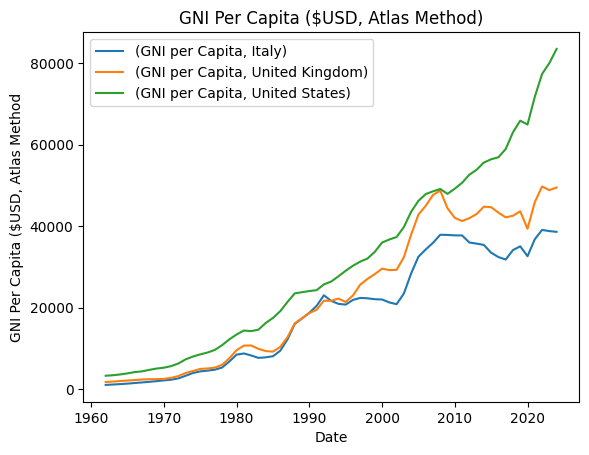

In [23]:
dfu.plot();
plt.legend(loc='best');
plt.title("GNI Per Capita ($USD, Atlas Method)");
plt.xlabel('Date');
plt.ylabel('GNI Per Capita ($USD, Atlas Method');

We can also plot two indicators together if we want to compare their trends.
Let us see the relationship between GDP and population un China.

We first select the country and indicators of interest.

In [26]:
chn = ['ITA']
start_year = 1990
end_year = 2021
gdp_indicator = {'NY.GDP.PCAP.CD':'GDP'}
pop_indicator = {'SP.POP.TOTL':'POP'}
co2_energy_indicator = {'CC.CO2.EMSE.EN': 'ENG'}

Then get the data by calling the World Bank Data API.

In [27]:
gdp = wbdata.get_dataframe(gdp_indicator, country=chn, date=(str(start_year), str(end_year)))
pop = wbdata.get_dataframe(pop_indicator , country=chn, date=(str(start_year), str(end_year)))
co2_energy = wbdata.get_dataframe(co2_energy_indicator , country=chn, date=(str(start_year), str(end_year)))

To make the two indicators comparable in out plot we standardise them.

In [28]:
gdp = (gdp-gdp.mean())/gdp.std()
pop = (pop-pop.mean())/pop.std()
co2_energy = (co2_energy-co2_energy.mean())/co2_energy.std()

And then make sure that years are in the right order.

In [29]:
gdp = gdp.sort_index(ascending=True)
pop = pop.sort_index(ascending=True)
co2_energy = co2_energy.sort_index(ascending=True)

We then plot the two indicators.

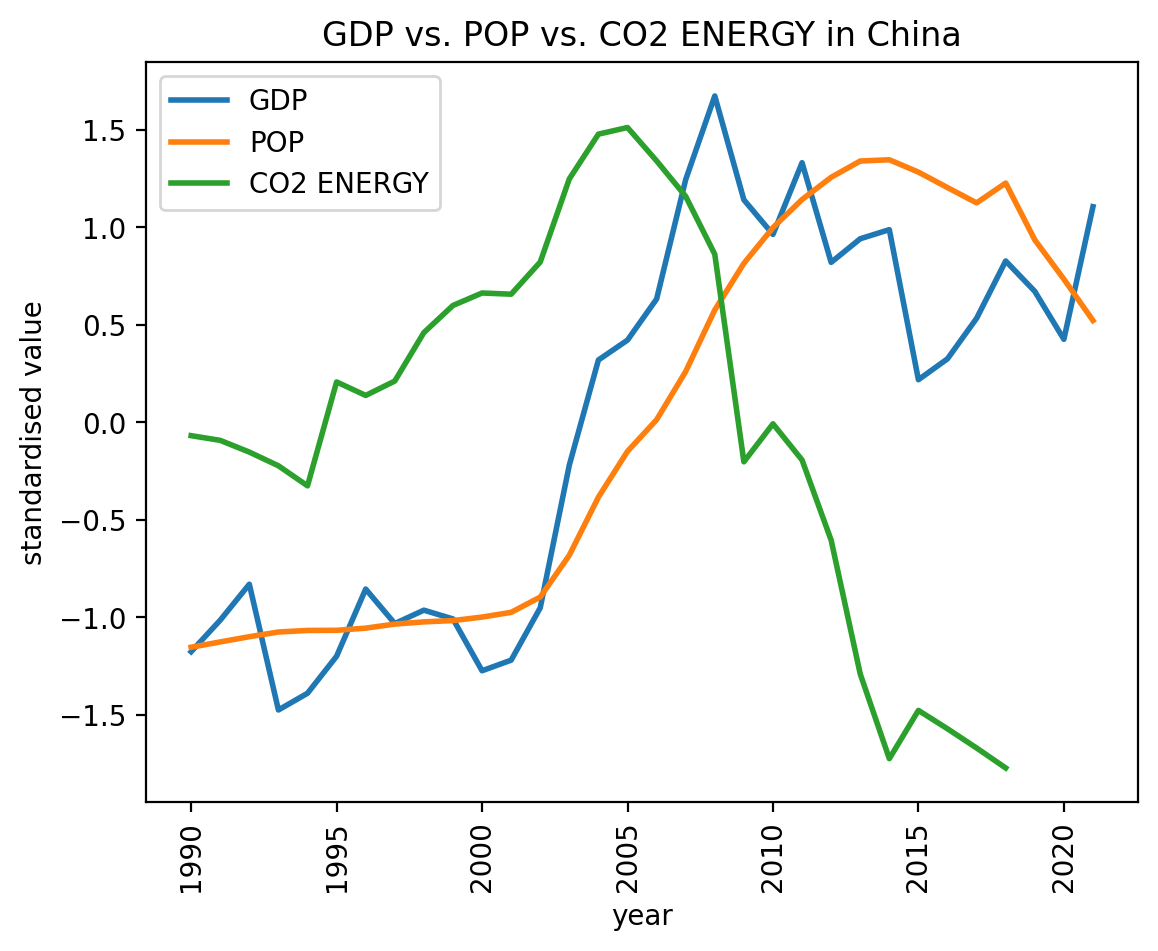

In [30]:
fig, ax = plt.subplots(dpi=200)
plt.rcParams.update({'font.size': 10})
fig.subplots_adjust(wspace=0)
ax.plot(gdp, linewidth=2.0, label='GDP')
ax.plot(pop, linewidth=2.0, label='POP')
ax.plot(co2_energy, linewidth=2.0, label='CO2 ENERGY')
plt.xticks(rotation='vertical')
plt.xticks(np.arange(0, 31, 5))
plt.title('GDP vs. POP vs. CO2 ENERGY in China');
plt.xlabel('year');
plt.ylabel('standardised value');
plt.legend()

# **Exercise**

Download the first 10000 violent incidents across the world reported in 2020 by the Uppsala Conflict Data Program and create plots as indicated, following examples in the past tutorials and examples contained in the plotting_example.ipynb file.

1. Familiarize yourself with the [API documentation](https://ucdp.uu.se/apidocs/), formulate a query to download the data and return the response as a dataframe following the example above.

2. After checking that you have downloaded the data correctly and what information is available, create a barchart reporting violent incidents by country.

3. Create a second barchart like the one above but using colors to differentiate types of violence. Make sure a legend and labels are present.

4. Side by side, create three histograms reporting the distribution of violent incidents by type of violence in the sample population of countries.

**Exercise 1**

In [32]:
# insert code below
import requests
import json
import pandas

In [44]:
url =

https://ucdpapi.pcr.uu.se/api/gedevents/v1?pagesize=10000&year=2020
<Response [400]>


**Exercise 2**

In [ ]:
# insert code below


**Exercise 3**

In [ ]:
# insert code below


**Exercise 4**

In [ ]:
# insert code below
